In [18]:
import fitz
import re, os
from pathlib import Path
import random
import time
from collections import Counter
from io import StringIO
import pandas as pd

NUM_LINE_RE = re.compile(
    r"^\s*[\(\[\{]?\s*[₹$€£]?\s*[-+]?"
    r"\d[\d,]*(?:\.\d+)?%?"
    r"\s*[\)\]\}]?\s*$"
)

SECTION_RE = re.compile(
    r"\b(?:financial\s+statements|standalone|consolidated|balance\s+sheet|profit\s+(?:&|and)\s+loss|cash\s+flow)\b",
    re.I
)

In [21]:
def gen_prb(st,et, n_lines=25):
    rng = random.Random(42) #seed
    lines = sorted(
        rng.uniform(st,et)
        for _ in range(n_lines)
    )
    return lines

def page_layout_metadata(page, ref_width, ref_height):
    w = page.rect.width
    h = page.rect.height

    spread = (w / ref_width) > 1.6 and (h / ref_height) > 0.7

    return {
        "width": int(w),
        "height": int(h),
        # "area": round(w * h, 2),
        # "rotation": page.rotation,
        "spread": spread,
        "split_x": round(w * 0.5, 2) if spread else None,
    }

def page_content_metadata_v1(page, layout, region):

    margin_x = (region["x1"] - region["x0"]) * 0.05
    margin_y = (region["y1"] - region["y0"]) * 0.15

    left = region["x0"] + margin_x
    right = region["x1"] - margin_x
    top = region["y0"] + margin_y
    bottom = region["y1"] - margin_y

    numeric_data = []
    segment_lines = []

    dirs = Counter()

    # char_count = 0
    line_count = 0
    block_count = 0

    blocks = page.get_text("dict")["blocks"]

    for block in blocks:

        if block["type"] != 0:
            continue
        
        block_count += 1
        
        for line in block["lines"]:

            x0, y0, x1, y1 = line["bbox"]

            # region restriction
            if x1 < left or x0 > right or y1 < top or y0 > bottom:
                continue
            
            line_count += 1
            spans = line["spans"]
            dirs[tuple(map(round, line["dir"]))] += 1
            text = "".join(span["text"] for span in spans).strip()

            if not text:
                continue
            # char_count += len(text)
            
            if NUM_LINE_RE.match(text):
                numeric_data.append(
                    {
                        "text": text,
                        "bbox": (x0, y0, x1, y1),
                        # IMPORTANT
                        "cx": (x0 + x1) / 2,
                    }
                )

            matches = SECTION_RE.findall(text)
            if matches:
                segment_lines.extend(matches)

    if dirs:

        dominant = dirs.most_common(1)[0][0]

        text_dir = {
            (1, 0): "n",
            (0, -1): "90_cc",
            (0, 1): "90_c",
            (-1, 0): "ud",
        }.get(dominant, "n")

    else:
        text_dir = None

    numeric_count = len(numeric_data)
    
    return {
        **layout,
        # "char_count": char_count,
        "line_count": line_count,
        "block_count": block_count,
        "t_dir": text_dir,
        "numeric_lines": numeric_data,
        "numeric_count": numeric_count,
        # "segment_lines": segment_lines,
        "segment_count": len(segment_lines),
        "probe_x": None if not numeric_count else gen_prb(region["x0"], region["x1"]),
        "probe_y": None if not numeric_count else gen_prb(region["y0"], region["y1"])
    }

def page_probe_metadata_v1(metadata):

    probes = metadata["probe_x"]
    yprobes = metadata["probe_y"]
    
    # print(f"X_PROBE: {probes} || Y_PROBE: {yprobes}")
    
    if not probes:
        metadata.update({
            "probe_x_hits":[],
            "probe_y_hits":[],
            # "max_hits":0,
            # "total_hits":0,
            # "hits_1":0,
            # "const_hit":0
        })
        
        return metadata
    
    xhits = [0] * len(probes)
    yhits = [0] * len(probes)
    # For X
    for item in metadata["numeric_lines"]:
        x0, _, x1, _ = item["bbox"]
        for i, px in enumerate(probes):
            if x0 <= px <= x1:
                xhits[i] += 1
    # For Y       
    for item in metadata["numeric_lines"]:
        _, y0, _, y1 = item["bbox"]
        for i, px in enumerate(yprobes):
            if y0 <= px <= y1:
                yhits[i] += 1

    metadata["probe_x_hits"] = xhits
    metadata["probe_y_hits"] = yhits
    # metadata["max_hits"] = max(hits)
    # metadata["total_hits"] = sum(hits)
    # metadata["hits_1"] = sum(h > 1 for h in hits)
    # metadata["cons_hit"] = consecutive_hits(hits, threshold=1)
    
    return metadata

def consecutive_hits(hits, threshold=0):
    longest = 0
    current = 0
    for h in hits:
        if h > threshold:
            current += 1
            longest = max(longest, current)
        else:
            current = 0
    return longest
    

In [30]:
#split run code
folder_path = r"C:\Users\kaustubh.keny\Projects\INPUTS\ANNUAL_REPORTS\ANNUAL_REPORTS_2025"

probe_data = []
pdf_data = []
files = os.listdir(folder_path)[:5]
total_files = len(files)

for idx,file in enumerate(files):
    print(f"{idx}/ {total_files}: {file}")
    pdf_path = os.path.join(folder_path, file)
    pdf_file = Path(pdf_path)
    doc = fitz.open(pdf_path)
    total_pages = doc.page_count
    
    rh = doc[0].rect.height
    rw = doc[0].rect.width
    
    start_t = time.perf_counter()
    for page_no, page in enumerate(doc):

        layout = page_layout_metadata(page, rw, rh)
        w = layout["width"]
        h = layout["height"]

        if layout["spread"]:

            split_x = layout["split_x"]

            # LEFT PAGE
            left_region = {"x0": 0, "y0": 0, "x1": split_x, "y1": h}
            left_metadata = { "pdf": pdf_file.stem,"page_n": page_no + 1,"side": "L" }
            temp = page_content_metadata_v1(page, layout, left_region)
            left_metadata.update(temp)
            left_metadata = page_probe_metadata_v1(left_metadata)
            probe_data.append(left_metadata)

            # RIGHT PAGE
            right_region = {"x0": split_x, "y0": 0, "x1": w, "y1": h}
            right_metadata = { "pdf": pdf_file.stem, "page_n": page_no + 1, "side": "R" }
            temp = page_content_metadata_v1(page, layout, right_region)
            right_metadata.update(temp)
            right_metadata = page_probe_metadata_v1(right_metadata)
            probe_data.append(right_metadata)

        else:
            region = {"x0": 0,"y0": 0,"x1": w,"y1": h}
            metadata = { "pdf":pdf_file.stem,"page_n": page_no + 1,"side":"S" }
            temp = page_content_metadata_v1(page, layout, region)
            metadata.update(temp)
            metadata = page_probe_metadata_v1(metadata)
            probe_data.append(metadata)
            
    end_t = time.perf_counter()
    
    pdf_data.append(
        {
            "pdf_name":pdf_file.stem,
            "total_pages":total_pages,
            "file_size":os.path.getsize(pdf_path),
            "time_elapsed": end_t - start_t
        }
    )

0/ 5: 2025_ABB.pdf
1/ 5: 2025_ABDL.pdf
2/ 5: 2025_ABSLAMC.pdf
3/ 5: 2025_ACC.pdf
4/ 5: 2025_ACI.pdf


In [ ]:
df = pd.DataFrame(probe_data)
df.columns


Index(['pdf', 'page_n', 'side', 'width', 'height', 'spread', 'split_x',
       'line_count', 'block_count', 't_dir', 'numeric_lines', 'numeric_count',
       'segment_count', 'probe_x', 'probe_y', 'probe_x_hits', 'probe_y_hits'],
      dtype='object')

In [32]:
#X
df["max_x_hits"] = df["probe_x_hits"].apply(lambda x: max(x) if x else 0)
df["total_x_hits"] = df["probe_x_hits"].apply(lambda x: sum(x) if x else 0)
df["x_hits>1"] = df["probe_x_hits"].apply(lambda x : sum(i> 1 for i in x) if x else 0)
df["x_cons_hit"] = df["probe_x_hits"].apply(lambda x: consecutive_hits(x, threshold=1) if x else 0)
#Y
df["max_y_hits"] = df["probe_y_hits"].apply(lambda x: max(x) if x else 0)
df["total_y_hits"] = df["probe_y_hits"].apply(lambda x: sum(x) if x else 0)
df["y_hits>1"] = df["probe_y_hits"].apply(lambda x : sum(i> 1 for i in x) if x else 0)
df["y_cons_hit"] = df["probe_y_hits"].apply(lambda x: consecutive_hits(x, threshold=1) if x else 0)

In [33]:
df.columns

Index(['pdf', 'page_n', 'side', 'width', 'height', 'spread', 'split_x',
       'line_count', 'block_count', 't_dir', 'numeric_lines', 'numeric_count',
       'segment_count', 'probe_x', 'probe_y', 'probe_x_hits', 'probe_y_hits',
       'max_x_hits', 'total_x_hits', 'x_hits>1', 'x_cons_hit', 'max_y_hits',
       'total_y_hits', 'y_hits>1', 'y_cons_hit'],
      dtype='object')

In [34]:
ndf = df.drop(["spread","split_x","probe_x","probe_y"],axis = 1)

In [ ]:
fp = Path(folder_path)
excel_path = f"{fp.stem}_HITS.xlsx"
df1 = pd.DataFrame(pdf_data)
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    ndf.to_excel(writer, sheet_name ="page_wise" ,index=False)
    df1.to_excel(writer,sheet_name ="pdf_wise",index=False)

In [83]:
# ndf.columns
data = ndf[(ndf["pdf"] == "2025_ABDL")].reindex()
data.head(5)

,pdf,page_n,side,width,height,line_count,block_count,t_dir,numeric_lines,numeric_count,...,probe_x_hits,probe_y_hits,max_x_hits,total_x_hits,x_hits>1,x_cons_hit,max_y_hits,total_y_hits,y_hits>1,y_cons_hit
349,2025_ABDL,1,S,612,792,59,9,n,[],0,...,[],[],0,0,0,0,0,0,0,0
350,2025_ABDL,2,S,595,841,0,0,None,[],0,...,[],[],0,0,0,0,0,0,0,0
351,2025_ABDL,3,L,1190,841,35,31,n,[],0,...,[],[],0,0,0,0,0,0,0,0
352,2025_ABDL,3,R,1190,841,43,31,n,"[{'text': '02', 'bbox': (705.8267211914062, 22...",16,...,"[0, 0, 0, 0, 0, 0, 11, 0, 0, 0, 0, 0, 0, 0, 5,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, ...",11,16,2,1,2,3,1,1
353,2025_ABDL,4,L,1190,841,20,41,n,[],0,...,[],[],0,0,0,0,0,0,0,0


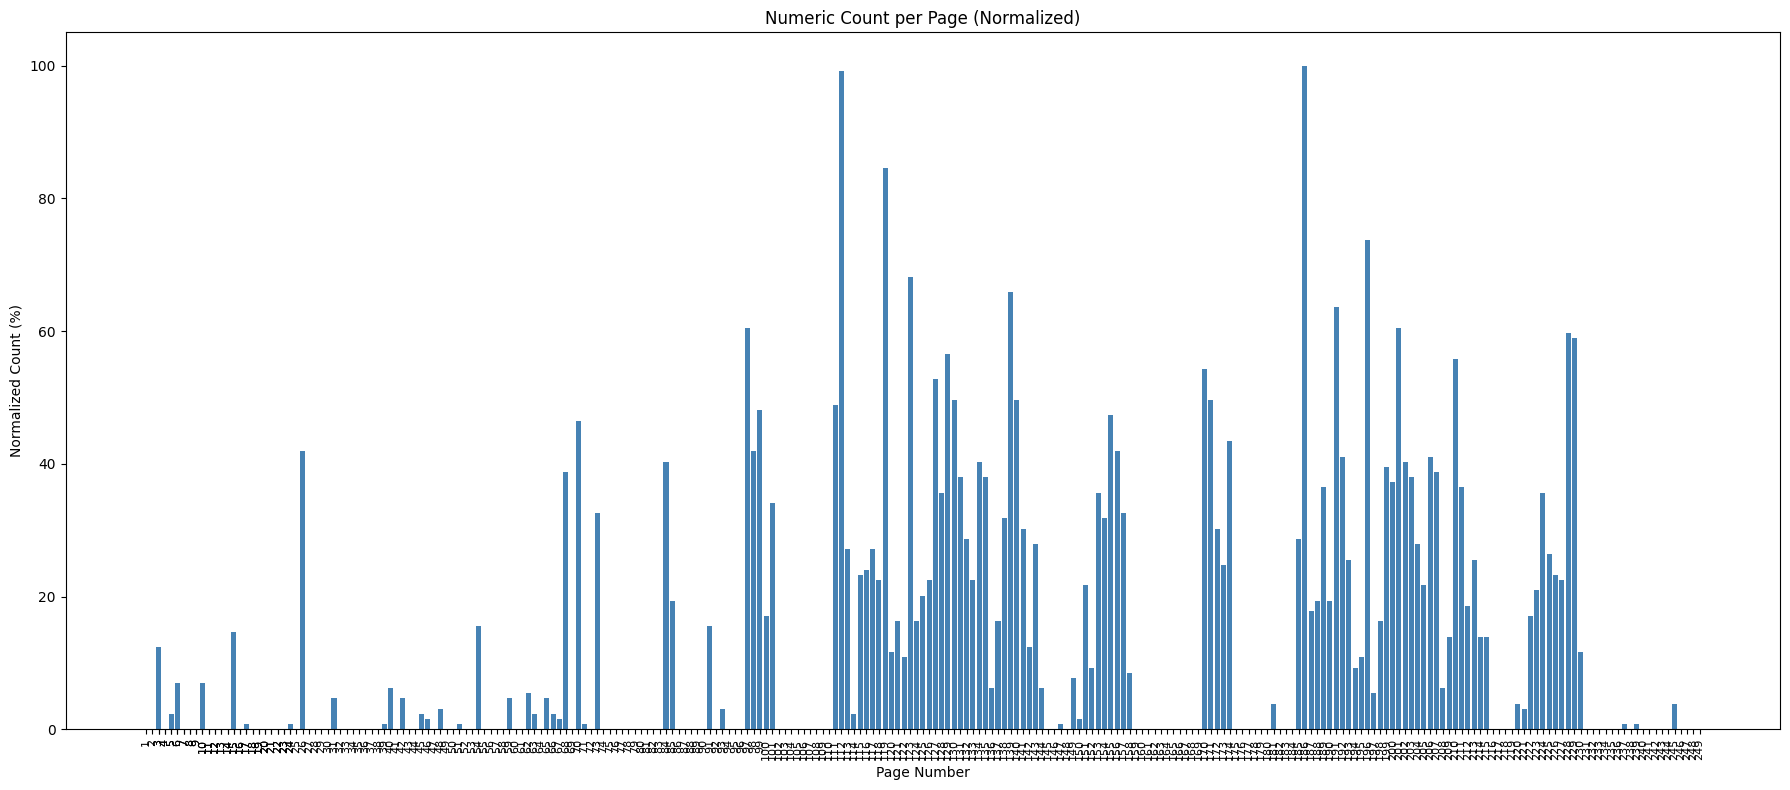

In [85]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18,8))

y = data.total_x_hits

# Normalize by max
normalized = (y / y.max()) * 100

# Use index positions for bars (0,1,2,...)
labels = data.page_n
ax.bar(labels, normalized, color="steelblue")

# Labels
ax.set_title("Numeric Count per Page (Normalized)")
ax.set_xlabel("Page Number")
ax.set_ylabel("Normalized Count (%)")

# Custom tick labels: show actual page numbers
ax.set_xticks(labels)
ax.set_xticklabels(labels, rotation=90, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
import requests

url = "https://www.sebi.gov.in/sebiweb/other/OtherAction.do"

params = {
    "doPmr": "yes",
    "currdate": "",
    "loginflag": "0",
    "searchValue": "",
    "pmrId": "INP000004565@@INP000004565@@360 ONE ASSET MANAGEMENT LIMITED",
    "year": "2026",
    "month": "3",
    "format": ""
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, params=params, headers=headers)

print(response.status_code)
print(response.url)
print(response.text[:1000])